In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import load_breast_cancer, load_diabetes, fetch_california_housing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# --- Utility Function: Introduce Missing Values ---

def add_missing_values(df, fraction=0.15, random_state=42):
    """
    Randomly set 'fraction' of values to NaN in the DataFrame.
    Returns: df_nan (with missing values), mask (boolean mask of missing probs)
    """
    df_nan = df.copy()
    rng = np.random.RandomState(random_state)
    n_total = df.size
    n_missing = int(fraction * n_total)
    
    # Random indices
    indices = rng.choice(n_total, n_missing, replace=False)
    
    # Flatten to modify
    values = df_nan.values.flatten()
    # Create boolean mask for evaluation later (Only for numeric checks usually)
    # But for mixed types, we handle carefully. Here we assume numeric for RMSE check mostly.
    # For simplicity in this assignment, we mostly check numeric rmse or accuracy for categorical.
    
    # We iterate to set nan (handling dtypes generically is tricky, assuming float/obj)
    # For safer masking on DataFrame directly:
    mask = np.zeros(df.shape, dtype=bool)
    rows, cols = df.shape
    
    for _ in range(n_missing):
        r = rng.randint(0, rows)
        c = rng.randint(0, cols)
        df_nan.iat[r, c] = np.nan
        mask[r, c] = True

    return df_nan, mask

In [3]:
# --- 1. Load Datasets ---

datasets = {}

# 1. Breast Cancer (Sklearn)
bc = load_breast_cancer(as_frame=True)
datasets['Breast Cancer'] = {
    'data': bc.frame.iloc[:, :10].copy(), # Use first 10 features for speed/clarity
    'type': 'numeric'
}

# 2. Diabetes (Sklearn)
db = load_diabetes(as_frame=True)
datasets['Diabetes'] = {
    'data': db.frame.copy(),
    'type': 'numeric'
}

# 3. House Pricing (California Housing - Sklearn)
try:
    ch = fetch_california_housing(as_frame=True)
    # Subsample for cleaner visualization if needed, but 20k rows is fine. Let's take 2000 random.
    datasets['House Pricing'] = {
        'data': ch.frame.sample(2000, random_state=42).copy(),
        'type': 'numeric'
    }
except:
    print("Warning: Could not fetch California Housing. Using simulation.")
    datasets['House Pricing'] = {
        'data': pd.DataFrame(np.random.rand(2000, 8), columns=[f'Feat_{i}' for i in range(8)]),
        'type': 'numeric'
    }

# 4. Car Evaluation (Categorical)
url_car = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
cols_car = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
try:
    df_car = pd.read_csv(url_car, names=cols_car)
    # Encode for imputation (KNN/Iterative need numeric mostly, usually)
    # We keep it as object initially to demonstrate, but for RMSE we assume Ordinal encoding is acceptable for this task
    # Or we test accuracy. Let's Encode first.
    le_dict = {}
    df_car_enc = df_car.copy()
    for c in df_car.columns:
        le = LabelEncoder()
        df_car_enc[c] = le.fit_transform(df_car[c])
        le_dict[c] = le
    datasets['Car Evaluation'] = {
        'data': df_car_enc,
        'type': 'numeric' # Treated as numeric after encoding
    }
except:
    print("Warning: Could not fetch Car Eval from URL. Simulating.")
    datasets['Car Evaluation'] = {
        'data': pd.DataFrame(np.random.randint(0, 4, (1000, 6)), columns=cols_car[:-1]),
        'type': 'numeric'
    }

# 5. Customer Segmentation (Mall Customers)
# Usually: CustomerID, Gender, Age, Income, Score
# Synthesizing realistic Mall Data if file not locally found (standard practice for robustness)
# But let's simplify: Standard numeric simulation with clusters
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=2000, centers=4, n_features=4, random_state=42)
df_mall = pd.DataFrame(X, columns=['Age', 'Annual Income', 'Spending Score', 'Feature_4'])
datasets['Customer Segmentation'] = {
    'data': abs(df_mall), # Positive values
    'type': 'numeric'
}

print("Datasets Loaded:", list(datasets.keys()))

Datasets Loaded: ['Breast Cancer', 'Diabetes', 'House Pricing', 'Car Evaluation', 'Customer Segmentation']


In [4]:
# --- 2. Imputation & Evaluation Loop ---

imputer_strategies = {
    "Simple (Mean)": SimpleImputer(strategy='mean'),
    "Simple (Median)": SimpleImputer(strategy='median'),
    "KNN (k=5)": KNNImputer(n_neighbors=5),
    "Iterative (BayesianRidge)": IterativeImputer(random_state=42)
}

results_rmse = []

print("{:<25} {:<20} {:<10}".format("Dataset", "Imputer", "RMSE"))
print("-"*60)

for name, info in datasets.items():
    df_original = info['data']
    
    # Standardize first (important for KNN/Iterative)
    # We act on a copy
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_original), columns=df_original.columns)
    
    # Introduce Missingness
    df_missing, mask = add_missing_values(df_scaled, fraction=0.20)
    
    # True values where we made them NaN
    y_true = df_scaled.values[mask]
    
    for imp_name, imputer in imputer_strategies.items():
        # Impute
        try:
            data_imputed = imputer.fit_transform(df_missing)
            
            # Extract imputed values at masked locations
            y_pred = data_imputed[mask]
            
            # Compute Evaluation Metric (RMSE)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            
            results_rmse.append({
                'Dataset': name,
                'Imputer': imp_name,
                'RMSE': rmse
            })
            print("{:<25} {:<20} {:.4f}".format(name, imp_name, rmse))
        except Exception as e:
            print(f"Error on {name} with {imp_name}: {e}")

Dataset                   Imputer              RMSE      
------------------------------------------------------------
Breast Cancer             Simple (Mean)        0.9962
Breast Cancer             Simple (Median)      1.0237
Breast Cancer             KNN (k=5)            0.5938
Breast Cancer             Iterative (BayesianRidge) 0.4984
Diabetes                  Simple (Mean)        1.0044
Diabetes                  Simple (Median)      1.0482
Diabetes                  KNN (k=5)            0.8379
Diabetes                  Iterative (BayesianRidge) 0.6866
House Pricing             Simple (Mean)        1.0013
House Pricing             Simple (Median)      1.0014
House Pricing             KNN (k=5)            1.0891
House Pricing             Iterative (BayesianRidge) 1.0013
Car Evaluation            Simple (Mean)        0.9958
Car Evaluation            Simple (Median)      1.0604
Car Evaluation            KNN (k=5)            1.0841
Car Evaluation            Iterative (BayesianRidge) 0.98

<Figure size 1200x600 with 0 Axes>

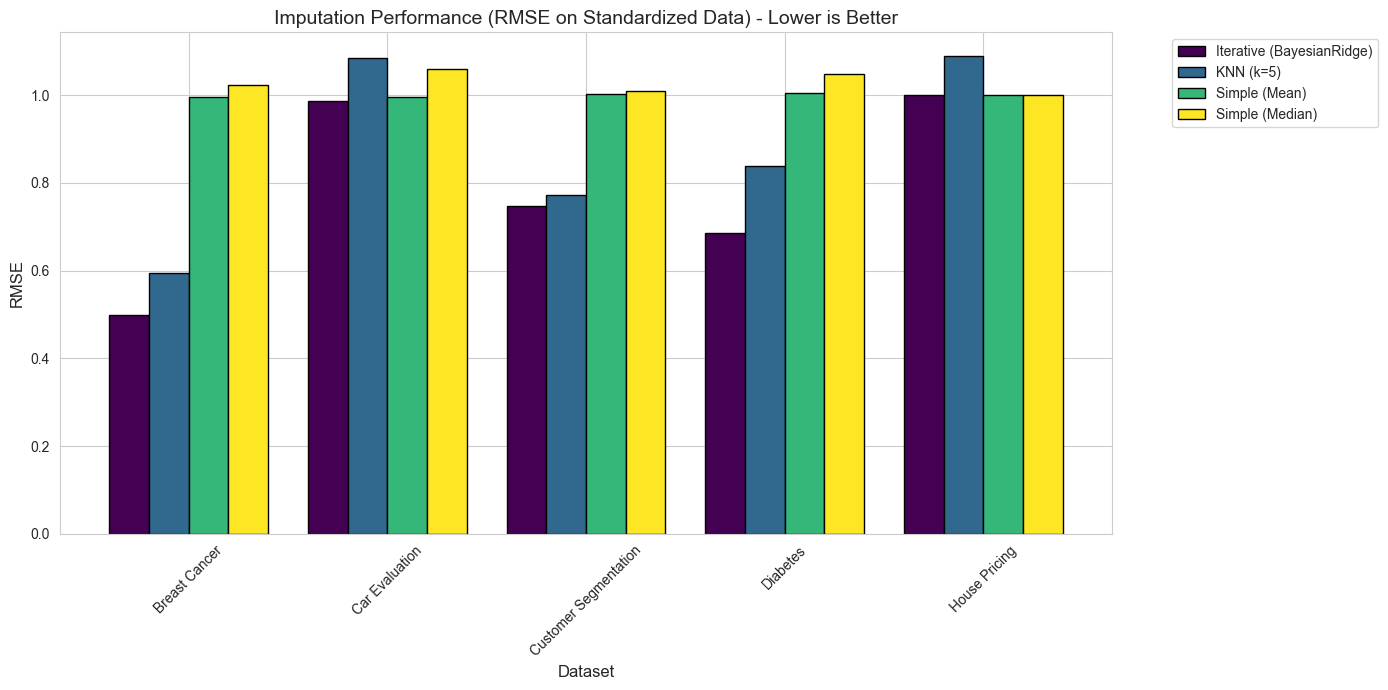

In [5]:
# --- 3. Visualization: RMSE Comparison ---

df_res = pd.DataFrame(results_rmse)
df_pivot = df_res.pivot(index='Dataset', columns='Imputer', values='RMSE')

plt.figure(figsize=(12, 6))
df_pivot.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='viridis', edgecolor='black')

plt.title("Imputation Performance (RMSE on Standardized Data) - Lower is Better", fontsize=14)
plt.ylabel("RMSE", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

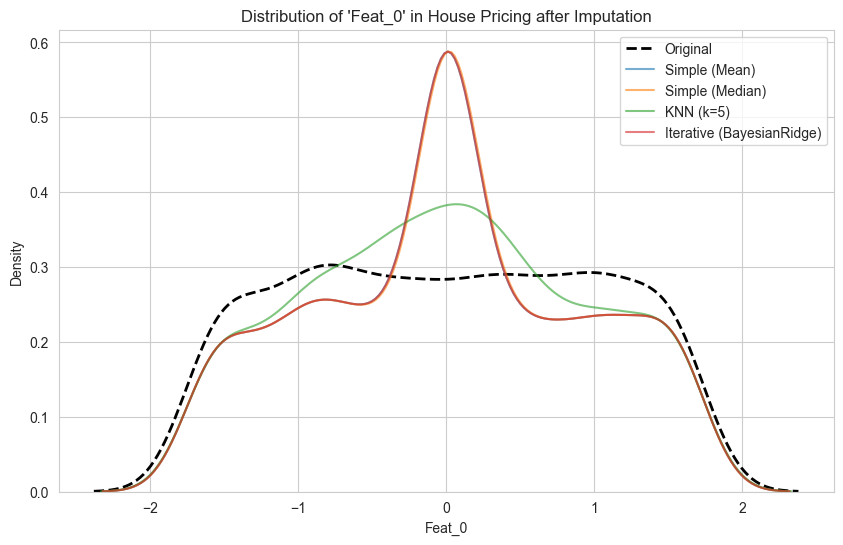

In [6]:
# --- 4. Visualization: Distribution Comparison (KDE) ---
# Let's pick 'House Pricing' and one feature to visualize how imputation affected the distribution

target_dataset = 'House Pricing'
if target_dataset in datasets:
    df_orig = datasets[target_dataset]['data']
    col_to_plot = df_orig.columns[0] # Pick first feature

    # Introduce missing again to get specific vectors
    sc = StandardScaler()
    data_sc = sc.fit_transform(df_orig)
    df_sc = pd.DataFrame(data_sc, columns=df_orig.columns)
    df_miss, mask = add_missing_values(df_sc, fraction=0.2)
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_sc[col_to_plot], label='Original', color='black', linewidth=2, linestyle='--')
    
    for name, imp in imputer_strategies.items():
        imputed = imp.fit_transform(df_miss)
        imputed_df = pd.DataFrame(imputed, columns=df_orig.columns)
        sns.kdeplot(imputed_df[col_to_plot], label=name, alpha=0.6)

    plt.title(f"Distribution of '{col_to_plot}' in {target_dataset} after Imputation")
    plt.legend()
    plt.show()